### IMPORT 

In [2]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt  
import re  
import string  
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords 
from wordcloud import WordCloud 


In [ ]:
import nltk 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to C:\Users\acer\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\acer\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
TKO_Df = pd.read_csv("./ulasan_TKO.csv")


In [6]:
TKO_Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34391 entries, 0 to 34390
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              34391 non-null  object
 1   userName              34391 non-null  object
 2   userImage             34391 non-null  object
 3   content               34391 non-null  object
 4   score                 34391 non-null  int64 
 5   thumbsUpCount         34391 non-null  int64 
 6   reviewCreatedVersion  25937 non-null  object
 7   at                    34391 non-null  object
 8   replyContent          28780 non-null  object
 9   repliedAt             28780 non-null  object
 10  appVersion            25937 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.9+ MB


In [7]:
clean_df = TKO_Df.drop(columns=["reviewId","userName","userImage","thumbsUpCount","reviewCreatedVersion","at","replyContent","repliedAt","appVersion"], inplace=True) 

In [8]:
clean_df = TKO_Df.dropna()

In [9]:
clean_df = TKO_Df.drop_duplicates()

In [10]:
clean_df.isna().sum()

content    0
score      0
dtype: int64

In [11]:
clean_df.shape

(32411, 2)

In [12]:
clean_df.head()

,content,score
0,"Isikan kode L A 5 5 Z B D 2 tanpa spasi ya, to...",5
1,"Aplikasinya sangat bagus. Fitur DCA, alert har...",5
2,Aplikasi TokoCrypto bener bener keren! bahkan ...,5
3,Tokocrypto ini cocok banget buat yang baru mau...,5
4,"Aplikasi simple cocok buat pemula, banyak pili...",5


<Axes: title={'center': 'Count of review by score'}, xlabel='score'>

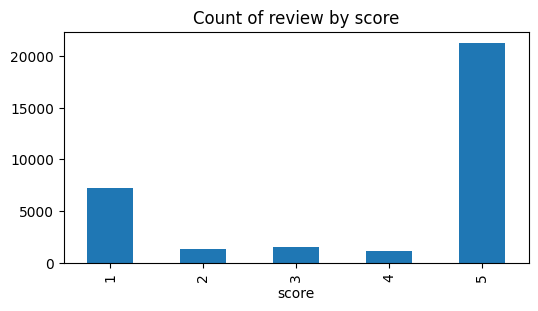

In [13]:
clean_df["score"].value_counts().sort_index().plot(kind="bar", title="Count of review by score", figsize=(6,3))

### TEXT PREPROCESSING

In [14]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana","bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "ga": "tidak","jualin": "menjual","omg": "astaga","cmn": "cuma","udh": "sudah","dlm": "dalam","sdh": "sudah","gmn": "bagaimana","sm": "sama","org": "orang","dmn": "di mana","bikin": "membuat","tokped": "Tokopedia","bukalap": "Bukalapak","shopee": "Shopee","trx": "transaksi","tokc": "Tokocrypto","kripto": "crypto","ngecek": "memeriksa","cuman": "cuma","sbg": "sebagai","smoga": "semoga"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [15]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) 
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text) 
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text) 
    text = re.sub(r'[^\w\s]', '', text)
 
    text = text.replace('\n', ' ') 
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    text = text.strip(' ')
    return text
def casefoldingText(text): 
    text = text.lower()     
    return text

def tokenizingText(text): 
        return word_tokenize(text,preserve_line=True)
   
def remove_stopword(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(["iya", "yaa", "gak", "yang", "dan", "di", "ke", "dari", "untuk", 
    "pada", "ada", "saja", "seperti", "karena", "jadi", "atau", "tapi", 
    "hanya", "sudah", "belum", "masih", "akan", "bisa", "tidak", "ini", 
    "itu", "lagi", "sama", "juga", "apa", "kalau", "mungkin", "dan", 
    "sedang", "dengan", "oleh", "dalam", "tersebut", "tentang", "adalah", 
    "dapat", "tanpa", "sampai", "hampir", "bagi", "dimana", "mengapa", 
    "bagaimana", "setelah", "sebelum", "maka", "namun", "seharusnya", 
    "kemudian", "terjadi", "nah", "lah", "kok", "dong", "loh", "kan", 
    "malah", "udah", "emang", "ya", "aja", "eh", "nih", "deh", "tuh"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
    
  
 
def toSentence(list_words): 
    sentence = ' '.join(word for word in list_words)
    return sentence

In [16]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangword'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangword'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(remove_stopword)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

C:\Users\acer\AppData\Local\Temp\ipykernel_10324\2895800441.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
C:\Users\acer\AppData\Local\Temp\ipykernel_10324\2895800441.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
C:\Users\acer\AppData\Local\Temp\ipykernel_10324\2895800441.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [17]:
clean_df.head()


,content,score,text_clean,text_casefoldingText,text_slangword,text_tokenizingText,text_stopword,text_akhir
0,"Isikan kode L A 5 5 Z B D 2 tanpa spasi ya, to...",5,Isikan kode L A Z B D tanpa spasi ya toko k...,isikan kode l a z b d tanpa spasi ya toko k...,isikan kode l a z b di tanpa spasi iya toko ke...,"[isikan, kode, l, a, z, b, di, tanpa, spasi, i...","[isikan, kode, l, z, b, spasi, toko, kertas, a...",isikan kode l z b spasi toko kertas aplikasi c...
1,"Aplikasinya sangat bagus. Fitur DCA, alert har...",5,Aplikasinya sangat bagus Fitur DCA alert harga...,aplikasinya sangat bagus fitur dca alert harga...,aplikasinya sangat bagus fitur dca alert harga...,"[aplikasinya, sangat, bagus, fitur, dca, alert...","[aplikasinya, bagus, fitur, dca, alert, harga,...",aplikasinya bagus fitur dca alert harga passke...
2,Aplikasi TokoCrypto bener bener keren! bahkan ...,5,Aplikasi TokoCrypto bener bener keren bahkan s...,aplikasi tokocrypto bener bener keren bahkan s...,aplikasi tokocrypto benar benar keren bahkan s...,"[aplikasi, tokocrypto, benar, benar, keren, ba...","[aplikasi, tokocrypto, keren, simpellll, gampa...",aplikasi tokocrypto keren simpellll gampang ba...
3,Tokocrypto ini cocok banget buat yang baru mau...,5,Tokocrypto ini cocok banget buat yang baru mau...,tokocrypto ini cocok banget buat yang baru mau...,tokocrypto ini cocok banget buat yang baru mau...,"[tokocrypto, ini, cocok, banget, buat, yang, b...","[tokocrypto, cocok, banget, investasi, crypto,...",tokocrypto cocok banget investasi crypto fitur...
4,"Aplikasi simple cocok buat pemula, banyak pili...",5,Aplikasi simple cocok buat pemula banyak pilih...,aplikasi simple cocok buat pemula banyak pilih...,aplikasi simple cocok buat pemula banyak pilih...,"[aplikasi, simple, cocok, buat, pemula, banyak...","[aplikasi, simple, cocok, pemula, pilihan, cry...",aplikasi simple cocok pemula pilihan crypto le...


### Labeling

In [18]:
def sentiment_score(text):
    sia = SentimentIntensityAnalyzer().polarity_scores(text)
    return sia["compound"]
def Labeling(score):
   label = "Positive" if score > 0 else ("Negative" if score < 0 else "Neutral")
   return label

In [19]:
clean_df["sentiment_score"] = clean_df["text_akhir"].apply(sentiment_score)
clean_df["Label"] = clean_df["sentiment_score"].apply(Labeling)

C:\Users\acer\AppData\Local\Temp\ipykernel_10324\2852859600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["sentiment_score"] = clean_df["text_akhir"].apply(sentiment_score)
C:\Users\acer\AppData\Local\Temp\ipykernel_10324\2852859600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["Label"] = clean_df["sentiment_score"].apply(Labeling)


In [20]:
clean_df.head()

,content,score,text_clean,text_casefoldingText,text_slangword,text_tokenizingText,text_stopword,text_akhir,sentiment_score,Label
0,"Isikan kode L A 5 5 Z B D 2 tanpa spasi ya, to...",5,Isikan kode L A Z B D tanpa spasi ya toko k...,isikan kode l a z b d tanpa spasi ya toko k...,isikan kode l a z b di tanpa spasi iya toko ke...,"[isikan, kode, l, a, z, b, di, tanpa, spasi, i...","[isikan, kode, l, z, b, spasi, toko, kertas, a...",isikan kode l z b spasi toko kertas aplikasi c...,0.5994,Positive
1,"Aplikasinya sangat bagus. Fitur DCA, alert har...",5,Aplikasinya sangat bagus Fitur DCA alert harga...,aplikasinya sangat bagus fitur dca alert harga...,aplikasinya sangat bagus fitur dca alert harga...,"[aplikasinya, sangat, bagus, fitur, dca, alert...","[aplikasinya, bagus, fitur, dca, alert, harga,...",aplikasinya bagus fitur dca alert harga passke...,0.2960,Positive
2,Aplikasi TokoCrypto bener bener keren! bahkan ...,5,Aplikasi TokoCrypto bener bener keren bahkan s...,aplikasi tokocrypto bener bener keren bahkan s...,aplikasi tokocrypto benar benar keren bahkan s...,"[aplikasi, tokocrypto, benar, benar, keren, ba...","[aplikasi, tokocrypto, keren, simpellll, gampa...",aplikasi tokocrypto keren simpellll gampang ba...,0.0000,Neutral
3,Tokocrypto ini cocok banget buat yang baru mau...,5,Tokocrypto ini cocok banget buat yang baru mau...,tokocrypto ini cocok banget buat yang baru mau...,tokocrypto ini cocok banget buat yang baru mau...,"[tokocrypto, ini, cocok, banget, buat, yang, b...","[tokocrypto, cocok, banget, investasi, crypto,...",tokocrypto cocok banget investasi crypto fitur...,0.2960,Positive
4,"Aplikasi simple cocok buat pemula, banyak pili...",5,Aplikasi simple cocok buat pemula banyak pilih...,aplikasi simple cocok buat pemula banyak pilih...,aplikasi simple cocok buat pemula banyak pilih...,"[aplikasi, simple, cocok, buat, pemula, banyak...","[aplikasi, simple, cocok, pemula, pilihan, cry...",aplikasi simple cocok pemula pilihan crypto le...,0.6369,Positive


<Axes: title={'center': 'Count of Sentiment Label'}, xlabel='Label'>

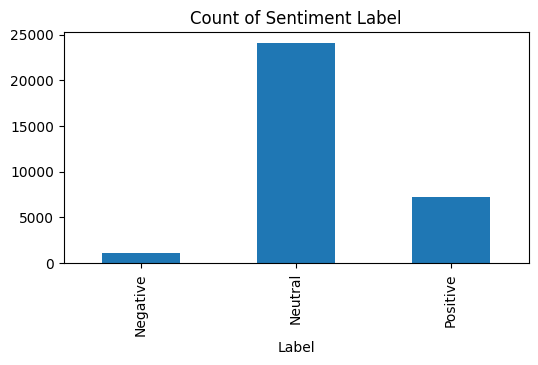

In [21]:
clean_df["Label"].value_counts().sort_index().plot(kind="bar", title="Count of Sentiment Label", figsize=(6,3))


In [22]:
negative_tweets = clean_df[clean_df['Label'] == 'Negative']["text_stopword"]
positive_tweets = clean_df[clean_df['Label'] == 'Positive']["text_stopword"]
neutral_tweets = clean_df[clean_df['Label'] == 'Neutral']["text_stopword"]


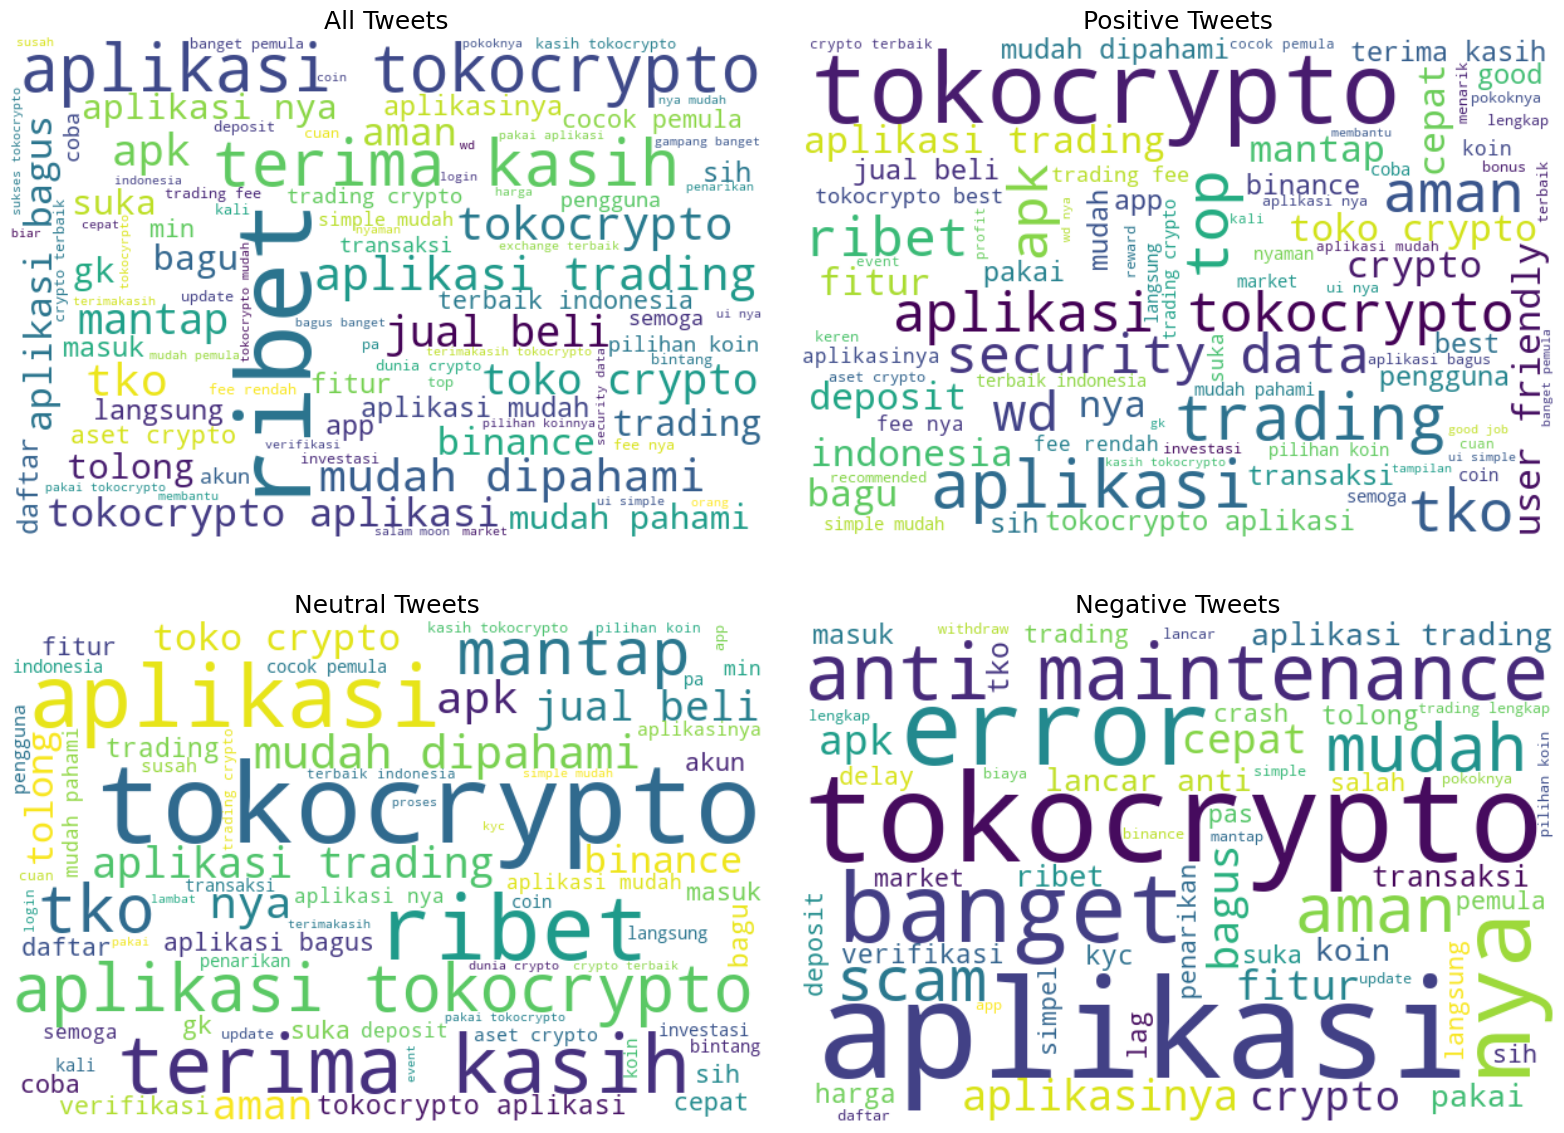

In [23]:
list_words = ' '.join([' '.join(tweet) for tweet in clean_df['text_stopword']])
list_positive_words = ' '.join([' '.join(tweet) for tweet in positive_tweets])
list_neutral_words = ' '.join([' '.join(tweet) for tweet in neutral_tweets])
list_negative_words = ' '.join([' '.join(tweet) for tweet in negative_tweets])

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
wordcloud_positive = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_positive_words)
wordcloud_neutral = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_neutral_words)
wordcloud_negative = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_negative_words)

fig, axes = plt.subplots(2, 2, figsize=(16, 12)) 
titles = ['All Tweets', 'Positive Tweets', 'Neutral Tweets', 'Negative Tweets']
wordclouds = [wordcloud, wordcloud_positive, wordcloud_neutral, wordcloud_negative]

for ax, wc, title in zip(axes.flatten(), wordclouds, titles):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=18)
    ax.axis('off')

plt.tight_layout(pad=2)
fig.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

### Ekstraksi fitur dan Modeling

In [31]:
import tensorflow as tf
import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding,LSTM,Dropout,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from gensim.models import Word2Vec

min_max = MinMaxScaler()
label_encoder = LabelEncoder()

In [32]:
X = clean_df["text_akhir"]
y = clean_df["Label"]

tfidf_vectorizer = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
X_tfidf = tfidf_vectorizer.fit_transform(X).toarray()

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(y)
y_one_hot = to_categorical(encoded_labels)

In [33]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    
    pickle.dump(tfidf_vectorizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

### split data 80/20, ekstraksi fitur tfidf ,Callback early_stopping

In [26]:

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_one_hot, test_size=0.2, random_state=120)

optimizer = Adam(learning_rate=0.0001)
model1 = Sequential()
model1.add(Dense(512, activation='relu', input_dim=X_train.shape[1]))
model1.add(Dropout(0.5))
model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dense(128, activation='relu', kernel_regularizer='l2'))
model1.add(Dropout(0.5))
model1.add(Dense(y_one_hot.shape[1], activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)



model1.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model1.fit(
    X_train, 
    y_train, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stopping],
    validation_split=0.2, 
    verbose=1
)

loss, accuracy_test1 = model1.evaluate(X_test, y_test, verbose=1)
loss, accuracy_train1 = model1.evaluate(X_train, y_train, verbose=1)
print(f"Test Accuracy: {accuracy_test1 * 100:.2f}%")
print(f"Train Accuracy: {accuracy_train1 * 100:.2f}%")



d:\LearnPy\DataScience\ppp\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6415 - loss: 2.3880 - val_accuracy: 0.8556 - val_loss: 1.6808
Epoch 2/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8038 - loss: 1.6149 - val_accuracy: 0.8943 - val_loss: 1.1822
Epoch 3/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8567 - loss: 1.1726 - val_accuracy: 0.9073 - val_loss: 0.8915
Epoch 4/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8749 - loss: 0.9126 - val_accuracy: 0.9130 - val_loss: 0.7055
Epoch 5/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8886 - loss: 0.7263 - val_accuracy: 0.9161 - val_loss: 0.5800
Epoch 6/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9016 - loss: 0.5981 - val_accuracy: 0.9173 - val_loss: 0.4987
Epoch 7/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9015 - loss: 0.5231 - val_accuracy: 0.9175 - val_loss: 0.4401
Epoch 8/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9058 - loss: 0.4580 - val_accu

### split data 70/30, ekstraksi fitur tfidf ,Callback early Stopping

In [27]:
scaled_x = min_max.fit_transform(X_tfidf)


X_train2, X_test2, y_train2, y_test2 = train_test_split(scaled_x, y_one_hot, test_size=0.3, random_state=42)

optimizer = Adam(learning_rate=0.05)
model2 = Sequential()
model2.add(Dense(128, activation='relu', input_dim=X_train2.shape[1]))
model2.add(Dropout(0.5))
model2.add(BatchNormalization(momentum=0.99))
model2.add(Dense(64, activation='relu', kernel_regularizer='l2'))
model2.add(Dropout(0.5))
model2.add(Dense(y_one_hot.shape[1], activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model2.fit(
    X_train2, 
    y_train2, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stopping],
    validation_split=0.3, 
    verbose=1
)

loss, accuracy_test2 = model2.evaluate(X_test2, y_test2, verbose=1)
loss, accuracy_train2 = model2.evaluate(X_train2, y_train2, verbose=1)
print(f"Test Accuracy: {accuracy_test2 * 100:.2f}%")
print(f"Train Accuracy: {accuracy_train2 * 100:.2f}%")



Epoch 1/100


d:\LearnPy\DataScience\ppp\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


497/497 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7467 - loss: 1.1623 - val_accuracy: 0.8719 - val_loss: 0.4916
Epoch 2/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8387 - loss: 0.5947 - val_accuracy: 0.8922 - val_loss: 0.4837
Epoch 3/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8508 - loss: 0.5747 - val_accuracy: 0.8729 - val_loss: 0.5091
Epoch 4/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8516 - loss: 0.5639 - val_accuracy: 0.9044 - val_loss: 0.4475
Epoch 5/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8650 - loss: 0.5405 - val_accuracy: 0.9069 - val_loss: 0.4287
Epoch 6/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8651 - loss: 0.5277 - val_accuracy: 0.9042 - val_loss: 0.4396
Epoch 7/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8601 - loss: 0.5294 - val_accuracy: 0.8917 - val_loss: 0.5128
Epoch 8/100
497/497 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8642 - loss: 0.5383 - val_accuracy: 0.9033

### split 80/20, ekstraksi fitur Word2Vec, Callback lr Callback

In [28]:


w2v_model = Word2Vec(sentences=clean_df["text_stopword"], vector_size=100, window=5, min_count=1, sg=1, workers=4, epochs=50)

def get_sentence_vector(model, sentence):
    words = [word for word in sentence if word in model.wv]
    if len(words) > 0:
        return np.mean(model.wv[words], axis=0)
    else:
        return np.zeros(model.vector_size)
    
X_features1 = np.array([get_sentence_vector(w2v_model, sentence) for sentence in clean_df["text_stopword"]])
encoded_labels1 = label_encoder.fit_transform(y)
y_one_hot1 = to_categorical(encoded_labels)


X_train1, X_test1, y_train1, y_test1 = train_test_split(X_features1, y_one_hot1, test_size=0.2, random_state=42)

optimizer = Adam(learning_rate=0.001)
model3 = Sequential()
model3.add(Dense(128, activation='relu', input_dim=X_train1.shape[1]))
model3.add(Dropout(0.5))
model3.add(BatchNormalization(momentum=0.99))
model3.add(Dense(64, activation='relu', kernel_regularizer='l2'))
model3.add(Dropout(0.5))
model3.add(Dense(y_one_hot1.shape[1], activation='softmax'))

lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

model3.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model3.fit(
    X_train1, 
    y_train1, 
    epochs=100, 
    batch_size=32, 
    callbacks=[lr_callback,],
    validation_split=0.2, 
    verbose=1
)

loss, accuracy_test3 = model3.evaluate(X_test1, y_test1, verbose=1)
loss, accuracy_train3 = model3.evaluate(X_train1, y_train1, verbose=1)
print(f"Test Accuracy: {accuracy_test3 * 100:.2f}%")
print(f"Train Accuracy: {accuracy_train3 * 100:.2f}%")



Epoch 1/100


d:\LearnPy\DataScience\ppp\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


649/649 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6634 - loss: 1.3997 - val_accuracy: 0.8079 - val_loss: 0.6261 - learning_rate: 0.0010
Epoch 2/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7822 - loss: 0.6299 - val_accuracy: 0.8251 - val_loss: 0.4796 - learning_rate: 0.0010
Epoch 3/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7961 - loss: 0.5249 - val_accuracy: 0.8245 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 4/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8075 - loss: 0.4976 - val_accuracy: 0.8380 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 5/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8115 - loss: 0.4942 - val_accuracy: 0.8398 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 6/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8145 - loss: 0.4806 - val_accuracy: 0.8440 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 7/100
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8187 - loss: 0.4751 - val_a

In [29]:
results_df = pd.DataFrame({
    'Model': ['Skema 1', 'Skema 2', 'Skema 3'],
    'Accuracy Train': [accuracy_train1, accuracy_train2, accuracy_train3],
    'Accuracy Test': [accuracy_test1, accuracy_test2, accuracy_test3]
})
results_df.sort_values(by="Accuracy Test", ascending=False)

,Model,Accuracy Train,Accuracy Test
0,Skema 1,0.925717,0.922258
1,Skema 2,0.904879,0.905492
2,Skema 3,0.912257,0.868117


In [30]:
model1.save('sentiment_model.h5')